In [1]:
import sys
import os

# Add the parent of the project root to sys.path
sys.path.append(os.path.abspath("../../"))

from src.config.default import get_cfg
from src.utils import load_model
from torchaudio.transforms import Resample
from PIL import Image
import pandas as pd
import torchvision


In [2]:
config = get_cfg("../../src/config/inference_wrapper.yml")
inference_wrapper = load_model(config)
#img = torchvision.io.read_image('/home/datasets/ecg-digitization/redacted/agnar_digital_redactions/IMG_1691.JPG')
#res = inference_wrapper(img.unsqueeze(0))
#res['snake']

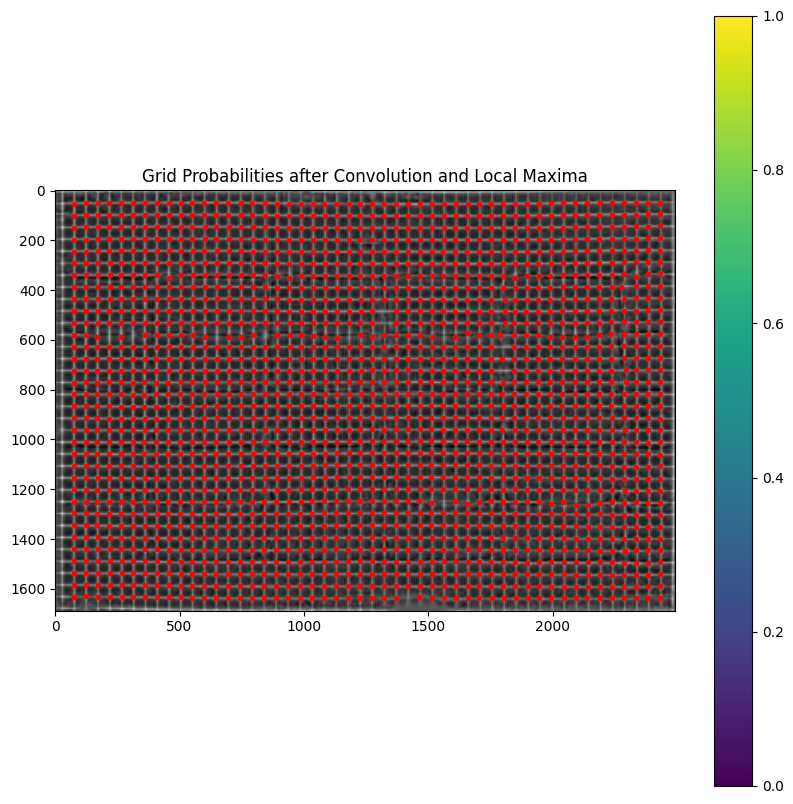

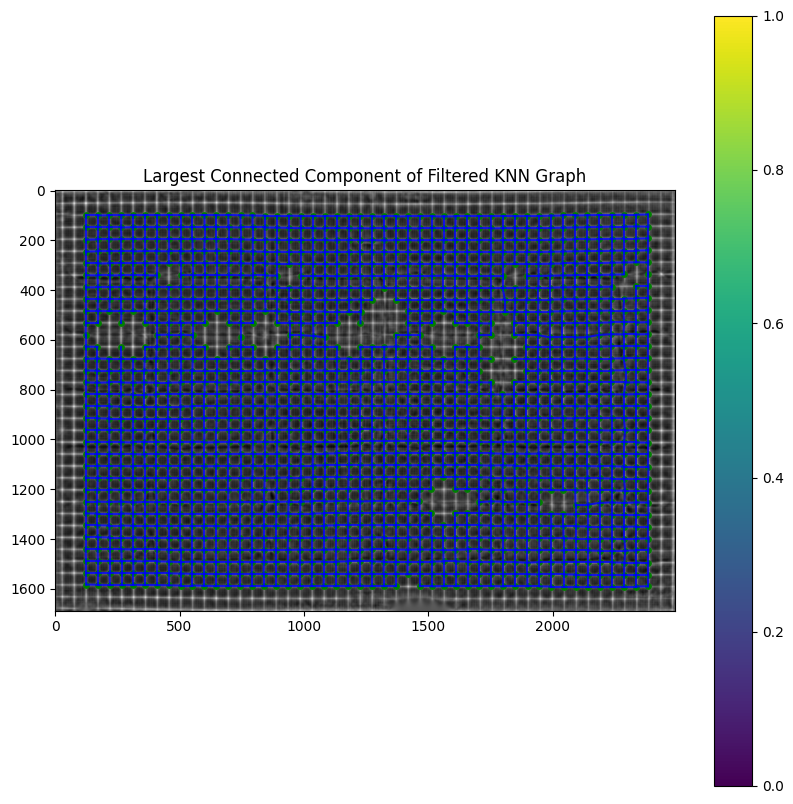

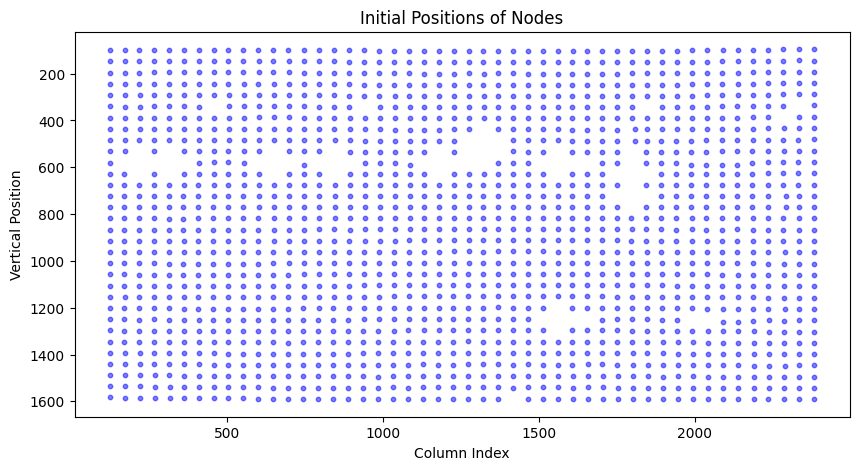

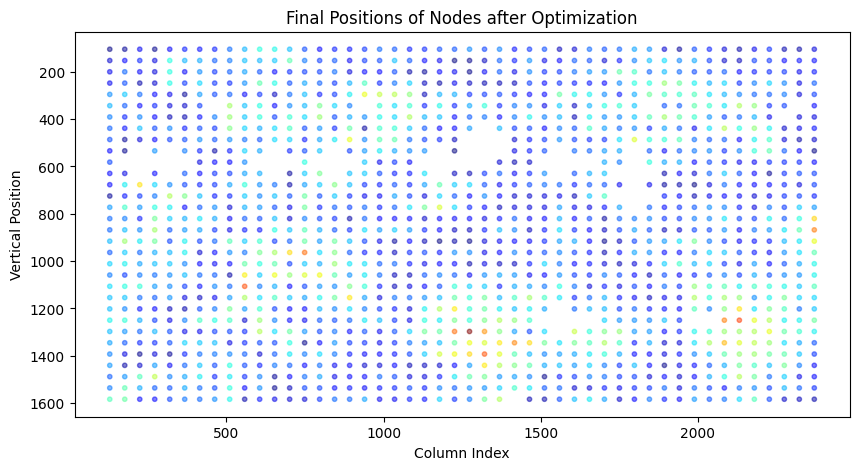

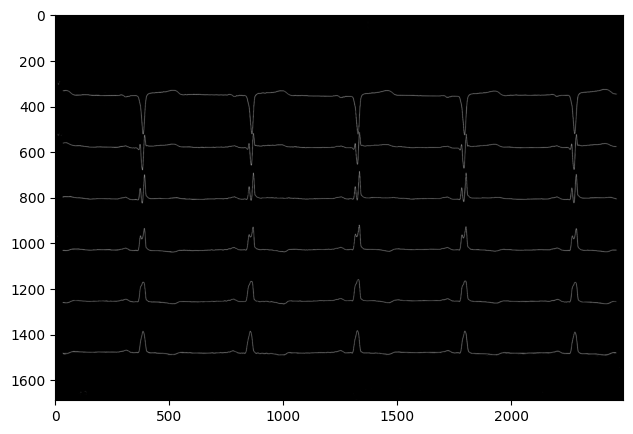

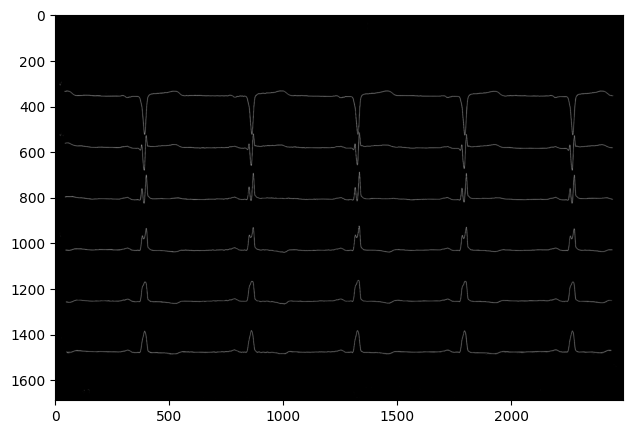

Profiling times
    Initial resampling      0.00s
    Segmentation            0.23s
    Perspective detection   0.59s
    Cropping                0.63s
    Feature map resampling  0.01s
    Pixel size search       0.65s
    Dewarping               4.17s
    Signal extraction       4.45s
Total time: 10.73s


In [3]:
ts_folder = '/home/datasets/ecg-digitization/csvs/'
ts_dfs_dict = {}

for file_name in os.listdir(ts_folder):
    file_path = os.path.join(ts_folder, file_name)
    ts_dfs_dict[file_name] = pd.read_csv(file_path)

ts_df = pd.concat(ts_dfs_dict.values(), keys=ts_dfs_dict.keys(), names=['file_name', 'index']).reset_index()
#print(ts_df[ts_df['file_name'] == ts_df['file_name'].unique()[0]].shape)
#print(ts_df[ts_df['file_name'] == ts_df['file_name'].unique()[0]])

image_path = '/home/datasets/ecg-digitization/redacted/agnar_digital_redactions/IMG_1691.JPG'

img = torchvision.io.read_image(image_path)
res = inference_wrapper(img.unsqueeze(0))

In [4]:
#ts_df[~ts_df['V4R'].isna()]['file_name'].unique()
#res['mm_per_pixel_x']


In [5]:
import torch

def autocorr_with_nans_vectorized(x, y, lags):
    """
    Vectorized cross-correlation with NaN handling across multiple lags.

    Args:
        x (torch.Tensor): shape (T,)
        y (torch.Tensor): shape (T,)
        lags (list or torch.Tensor): shape (L,)

    Returns:
        torch.Tensor: shape (L,), correlation coefficients for each lag
    """
    x = x.clone()
    y = y.clone()
    lags = torch.tensor(lags, dtype=torch.long)

    T = x.shape[0]
    L = lags.shape[0]

    # Allocate index tensors for each lag
    indices = torch.arange(T).expand(L, T)  # shape: (L, T)
    lagged_indices_x = indices.clone()

    lagged_indices_x = lagged_indices_x - lags.view(-1, 1)  # each row i: indices - lags[i]

    # Mask out-of-bounds indices
    valid_mask = (lagged_indices_x >= 0) & (lagged_indices_x < T)

    # Gather values (invalid indices will be masked out later)
    x_lagged = torch.where(
        valid_mask,
        x[lagged_indices_x.clamp(0, T - 1)],
        torch.tensor(float('nan'), device=x.device)
    )
    y_batched = y.unsqueeze(0).expand(L, y.shape[0])


    num_points = y_batched.shape[-1]
    if x_lagged.shape[-1] > num_points:
        start = x_lagged.shape[-1] // 2 - num_points // 2
        end = start + num_points
        x_lagged = x_lagged[:, start:end]
        valid_mask = valid_mask[:, start:end]
    elif x_lagged.shape[-1] < num_points:
        padding = num_points - x_lagged.shape[-1]
        x_lagged = torch.nn.functional.pad(x_lagged, (0, padding))
        valid_mask = torch.nn.functional.pad(valid_mask, (0, padding), value=False)

    # Mask NaNs
    combined_mask = valid_mask & ~torch.isnan(x_lagged) & ~torch.isnan(y_batched)

    x_valid = torch.where(combined_mask, x_lagged, torch.tensor(0.0, device=x.device))
    y_valid = torch.where(combined_mask, y_batched, torch.tensor(0.0, device=y.device))
    count_valid = combined_mask.sum(dim=1)

    # Mean centering
    x_sum = x_valid.sum(dim=1)
    y_sum = y_valid.sum(dim=1)

    x_mean = x_sum / count_valid.clamp(min=1)
    y_mean = y_sum / count_valid.clamp(min=1)

    x_centered = x_valid - x_mean.unsqueeze(1)
    y_centered = y_valid - y_mean.unsqueeze(1)

    numerator = (x_centered * y_centered * combined_mask).sum(dim=1)
    denominator = torch.sqrt(
        (x_centered**2 * combined_mask).sum(dim=1) *
        (y_centered**2 * combined_mask).sum(dim=1)
    )

    corr = numerator / denominator
    corr[count_valid < 2] = float('nan')  # not enough data

    return corr


def find_max_correlation(image_signal, ts, image_pixels_per_second, ts_sample_rate):
    resampled_image_signal = Resample(orig_freq=int(image_pixels_per_second), new_freq=ts_sample_rate)(image_signal)

    max_offset_time = 2
    max_offset_points = int(max_offset_time * ts_sample_rate)
    offsets = list(range(-max_offset_points, max_offset_points, 50))

    correlation = autocorr_with_nans_vectorized(resampled_image_signal, ts, offsets)
    return correlation.max(), (correlation.argmax() * 50 - max_offset_points) / ts_sample_rate


image_pixels_per_mm = inference_wrapper.dewarper.pixels_per_mm
image_mm_per_second = 50
signal_length_seconds = 5

image_pixels_per_second = image_pixels_per_mm * image_mm_per_second
image_signal_length_pixels = image_pixels_per_mm * image_mm_per_second * signal_length_seconds


import plotly.graph_objects as go
from IPython.display import display

scatter = go.Scatter(
    x=[], y=[], mode='markers',
    text=[], textposition='top center', hoverinfo='text+x+y',
    marker=dict(size=10)
)

fig = go.FigureWidget(data=[scatter])
display(fig)
correlations = []
correlation_indices = []
names = []

# Either:
#  - V1, V2, V3, V4, V5, V6
#  - aVL, I, -aVR, II, aVF, III


for idx, v in enumerate(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'aVL', 'I', 'aVR', 'II', 'aVF', 'III']):
    if v != 'aVL':
        continue

    for file_name in ts_df['file_name'].unique():
        #if '58_23_04' not in file_name:
        #    continue

        ts_signal_length_points = ts_df[ts_df['file_name'] == file_name].shape[0]
        ts_sample_rate = ts_signal_length_points // signal_length_seconds

        image_ts = res['snake'][idx % 6]
        ts = torch.tensor(ts_df[ts_df['file_name'] == file_name][v].values)

        if v == 'aVR':
            image_ts = -image_ts

        correlation, correlation_idx = find_max_correlation(image_ts, ts, image_pixels_per_second, ts_sample_rate)
        names.append(file_name + ' ' + v)
        correlations.append(correlation.item())
        correlation_indices.append(correlation_idx.item())
        print(f"File: {file_name}, Max Correlation: {correlation}, seconds off: {correlation_idx}")

        with fig.batch_update():
            fig.data[0].x = correlation_indices
            fig.data[0].y = correlations
            fig.data[0].text = names


FigureWidget({
    'data': [{'hoverinfo': 'text+x+y',
              'marker': {'size': 10},
              'mode': 'markers',
              'text': [],
              'textposition': 'top center',
              'type': 'scatter',
              'uid': '782d933b-1e9e-4855-9c92-41b9c1eba928',
              'x': [],
              'y': []}],
    'layout': {'template': '...'}
})

File: 685_14_03_2025_f09e06.csv, Max Correlation: nan, seconds off: -2.0


/home/agnar/dev/Electrocardiogram-Digitization/venv/lib/python3.12/site-packages/jupyter_client/session.py:721: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



File: 502_04_03_2025_2fca83.csv, Max Correlation: nan, seconds off: -2.0
File: 89_10_04_2025_71f8ea.csv, Max Correlation: nan, seconds off: -2.0
File: 548_25_02_2025_6faa89.csv, Max Correlation: nan, seconds off: -2.0
File: 39_22_04_2025_65639f.csv, Max Correlation: nan, seconds off: -2.0
File: 370_20_03_2025_25455c.csv, Max Correlation: nan, seconds off: -2.0
File: 185_01_04_2025_52de1c.csv, Max Correlation: nan, seconds off: -2.0
File: 483_28_02_2025_0bee9f.csv, Max Correlation: nan, seconds off: -2.0
File: 278_27_03_2025_a6517e.csv, Max Correlation: nan, seconds off: -2.0
File: 608_17_02_2025_3f0667.csv, Max Correlation: nan, seconds off: -2.0
File: 324_17_03_2025_c87b97.csv, Max Correlation: nan, seconds off: -2.0
File: 9_12_04_2025_9cb6c8.csv, Max Correlation: nan, seconds off: -2.0
File: 427_24_03_2025_25607b.csv, Max Correlation: nan, seconds off: -2.0
File: 53_23_04_2025_883c0a.csv, Max Correlation: nan, seconds off: -2.0
File: 307_25_03_2025_614e71.csv, Max Correlation: nan, s

In [ ]:

# Cut the signal in the middle to match the signal length.
#if resampled_image_signal.shape[1] > ts_signal_length_points:
#    w = resampled_image_signal.shape[1] // 2
#    start = w - ts_signal_length_points // 2
#    end = start + ts_signal_length_points
#    resampled_image_signal = resampled_image_signal[:, start:end]
#elif resampled_image_signal.shape[1] < ts_signal_length_points:
#    padding = ts_signal_length_points - resampled_image_signal.shape[1]
#    resampled_image_signal = torch.nn.functional.pad(resampled_image_signal, (0, padding))

#print(ts_signal_length_points)
#resampled_image_signal.shape


torch.Size([6, 10445])
10000


torch.Size([6, 10000])

In [ ]:
#print(resampled_image_signal[0], torch.tensor(ts_df[ts_df['file_name'] == ts_df['file_name'][0]]['V1']).shape)
#
#
#max_offset_time = 0.5
#max_offset_points = int(max_offset_time * ts_sample_rate)
#
#correlation = autocorr_with_nans_vectorized(resampled_image_signal[0], torch.tensor(ts_df[ts_df['file_name'] == ts_df['file_name'][0]]['V1']), list(range(-max_offset_points, max_offset_points)))
#correlation.max(), correlation.argmax()

tensor([nan, nan, nan,  ..., nan, nan, nan]) torch.Size([10000])


tensor([0.0450, 0.0449, 0.0448,  ..., 0.0683, 0.0676, 0.0668])

(tensor(0.1211), tensor(1875))